In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, root_mean_squared_error
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import AdaBoostRegressor
from load_data import get_dataset
from pipeline_tree_model import get_preprocessor

In [2]:
X_train, X_test, y_train, y_test = get_dataset()

In [3]:
preprocessor = get_preprocessor()

In [4]:
base_estimator = DecisionTreeRegressor(random_state=42)

In [5]:
pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("model", AdaBoostRegressor(estimator=base_estimator, random_state=42))
])

In [ ]:
params_grid = {
    "model__n_estimators": [30, 50, 100, 200],
    "model__learning_rate": [0.001, 0.01],
    "model__loss": ["linear", "square"],
    "model__estimator__max_depth": [3, 5],
    "model__estimator__min_samples_split": [2, 5],
    "model__estimator__min_samples_leaf": [1, 2]
}

In [7]:
grid = GridSearchCV(pipe, param_grid=params_grid, cv=5, scoring="neg_mean_absolute_error", verbose=1, n_jobs=-1)

In [8]:
grid.fit(X_train, y_train)

Fitting 5 folds for each of 128 candidates, totalling 640 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__estimator__max_depth': [3, 5], 'model__estimator__min_samples_leaf': [1, 2], 'model__estimator__min_samples_split': [2, 5], 'model__learning_rate': [0.001, 0.01], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_absolute_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher,

In [9]:
y_pred = grid.predict(X_test)

In [10]:
print("Training")
print("R2 Score", r2_score(y_train, grid.predict(X_train)))
print("MAE", mean_absolute_error(y_train, grid.predict(X_train)))
print("MSE", mean_squared_error(y_train, grid.predict(X_train)))
print("RMSE", root_mean_squared_error(y_train, grid.predict(X_train)))
print("\n")
print("Testing")
print("R2 Score", r2_score(y_test, y_pred))
print("MAE", mean_absolute_error(y_test, y_pred))
print("MSE", mean_squared_error(y_test, y_pred))
print("RMSE", root_mean_squared_error(y_test, y_pred))

Training
R2 Score 0.8777947147045707
MAE 2266.459563372705
MSE 17730812.970279746
RMSE 4210.79718940247


Testing
R2 Score 0.857627448427763
MAE 2550.7765167137104
MSE 21482756.569381747
RMSE 4634.949467834763


In [11]:
grid.best_params_

{'model__estimator__max_depth': 5,
 'model__estimator__min_samples_leaf': 2,
 'model__estimator__min_samples_split': 2,
 'model__learning_rate': 0.001,
 'model__loss': 'square',
 'model__n_estimators': 50}

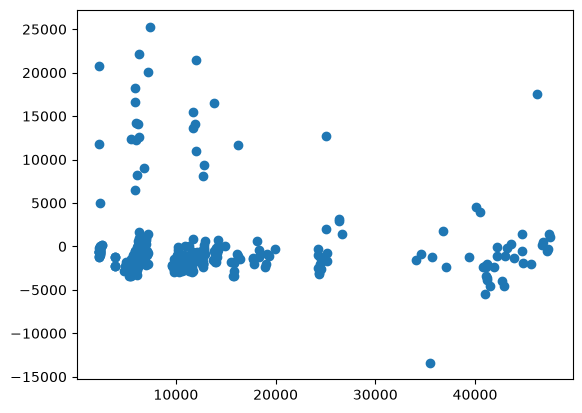

In [12]:
residuals = y_test - y_pred
plt.scatter(y_pred, residuals)
plt.show()